In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_simload
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import pygtc

In [33]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def plot_corner_with_corr(
    matched,
    colors=("steelblue", "darkorange"),
    figsize=12,
):
    """
    Plot a corner comparison between SatGen and Bolshoi using a
    matched dataframe, with correlation coefficients annotated in
    each off-diagonal panel.

    Expected columns:
        log1pz50_sat, logc_sat, logNsub_sat, logfsub_sat
        log1pz50_bol, logc_bol, logNsub_bol, logfsub_bol
    """

    keys = ["log1pz50", "logc", "logNsub", "logfsub"]

    paramNames = [
        "log (1 + z$_{50}$)",
        "logc",
        "logNsub",
        "logfsub",
    ]

    paramRanges = [
        [0.0, 0.55],
        [0.5, 1.3],
        [0.0, 1.5],
        [-2.8, 0],
    ]

    models = [("sat", "SatGen"), ("bol", "Bolshoi")]
    model_colors = dict(zip([m for _, m in models], colors))

    # build clean per-model chains + pairwise correlations
    model_chains = {}
    model_rho = {}

    for suffix, model in models:
        cols = [f"{k}_{suffix}" for k in keys]
        chain = matched[cols].copy()
        chain.columns = keys

        mask = ~chain.isna().any(axis=1)
        chain = chain.loc[mask].reset_index(drop=True)

        pair_rho = {}
        for k1, k2 in itertools.combinations(keys, 2):
            pair_rho[(k1, k2)] = jsm_stats.correlation(chain[k1], chain[k2])

        model_chains[model] = chain
        model_rho[model] = pair_rho

    nDim = len(keys)
    fig, axes = plt.subplots(
        nDim, nDim,
        figsize=(figsize, figsize),
    )

    for i in range(nDim):
        for j in range(nDim):
            ax = axes[i, j]

            if j > i:
                ax.axis("off")
                continue

            if i == j:
                # diagonal: 1D marginal
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(
                        chain[keys[i]],
                        ax=ax,
                        color=model_colors[model],
                        fill=False,
                        lw=1.8,
                    )
                ax.set_xlim(paramRanges[i])
                ax.set_yticks([])

            else:
                # off-diagonal: 2D contours
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(
                        x=chain[keys[j]],
                        y=chain[keys[i]],
                        ax=ax,
                        color=model_colors[model],
                        levels=levelz,
                        fill=False,
                        linewidths=1.3,
                    )
                ax.set_xlim(paramRanges[j])
                ax.set_ylim(paramRanges[i])

                # correlation annotation
                pair = (keys[j], keys[i])
                if pair not in model_rho["SatGen"]:
                    pair = (keys[i], keys[j])

                y0 = 0.85
                for _, model in models:
                    rho = model_rho[model][pair]
                    ax.text(
                        0.7, y0,
                        f"$\\rho$={rho:.2f}",
                        transform=ax.transAxes,
                        fontsize=12,
                        color=model_colors[model],bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="k")
                    )
                    y0 -= 0.15

            # axis label / tick cleanup
            if i < nDim - 1:
                ax.set_xticklabels([])
                ax.set_xlabel("")
            else:
                ax.set_xlabel(paramNames[j], fontsize=12, fontfamily="Times")

            if j > 0 or i == j:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            else:
                ax.set_ylabel(paramNames[i], fontsize=12, fontfamily="Times")

            ax.tick_params(labelsize=10)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontfamily("Times")

    # legend proxies
    handles = [
        plt.Line2D([0], [0], color=model_colors[model], lw=1.8, label=model)
        for _, model in models
    ]
    fig.legend(
        handles=handles,
        loc="upper right",
        fontsize=12,
        frameon=False,
    )

    plt.subplots_adjust(wspace=0.08, hspace=0.08)
    plt.tight_layout()
    return fig

In [34]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [35]:
boltab = pd.read_csv("../../../misc/multidark/bolshoiP/BolshoiP_isolated_500.csv")
bolnorm = jsm_simload.NormalizeData(boltab, dataset_title="BolshoiP")

bin_min = 13.1
bin_max = 13.3
subsample = bolnorm.df[(bolnorm.df["logMvir"] > bin_min) & (bolnorm.df["logMvir"] < bin_max)]
bolshoi = subsample[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]]

In [51]:
vanilla = jsm_ancillary.load_massspec_z0("../../data/bolshoi_rep/cvir_test_new/zhao/", regime="artificial", conctype=None)
satgen_vanilla = vanilla[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]]

In [48]:
zhao = jsm_ancillary.load_massspec_z0("../../data/bolshoi_rep/cvir_test_new/zhao/", regime="artificial", conctype="measured")
satgen_zhao = zhao[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]]

In [49]:
ludlow = jsm_ancillary.load_massspec_z0("../../data/bolshoi_rep/cvir_test_new/ludlow/", regime="artificial", conctype="measured")
satgen_ludlow = ludlow[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]]

In [52]:
matched_vanilla = vanilla.merge(
    bolshoi,
    on="logMvir",
    how="inner",
    suffixes=("_sat", "_bol")
)

In [53]:
matched_zhao = satgen_zhao.merge(
    bolshoi,
    on="logMvir",
    how="inner",
    suffixes=("_sat", "_bol")
)

In [54]:
matched_ludlow = satgen_ludlow.merge(
    bolshoi,
    on="logMvir",
    how="inner",
    suffixes=("_sat", "_bol")
)

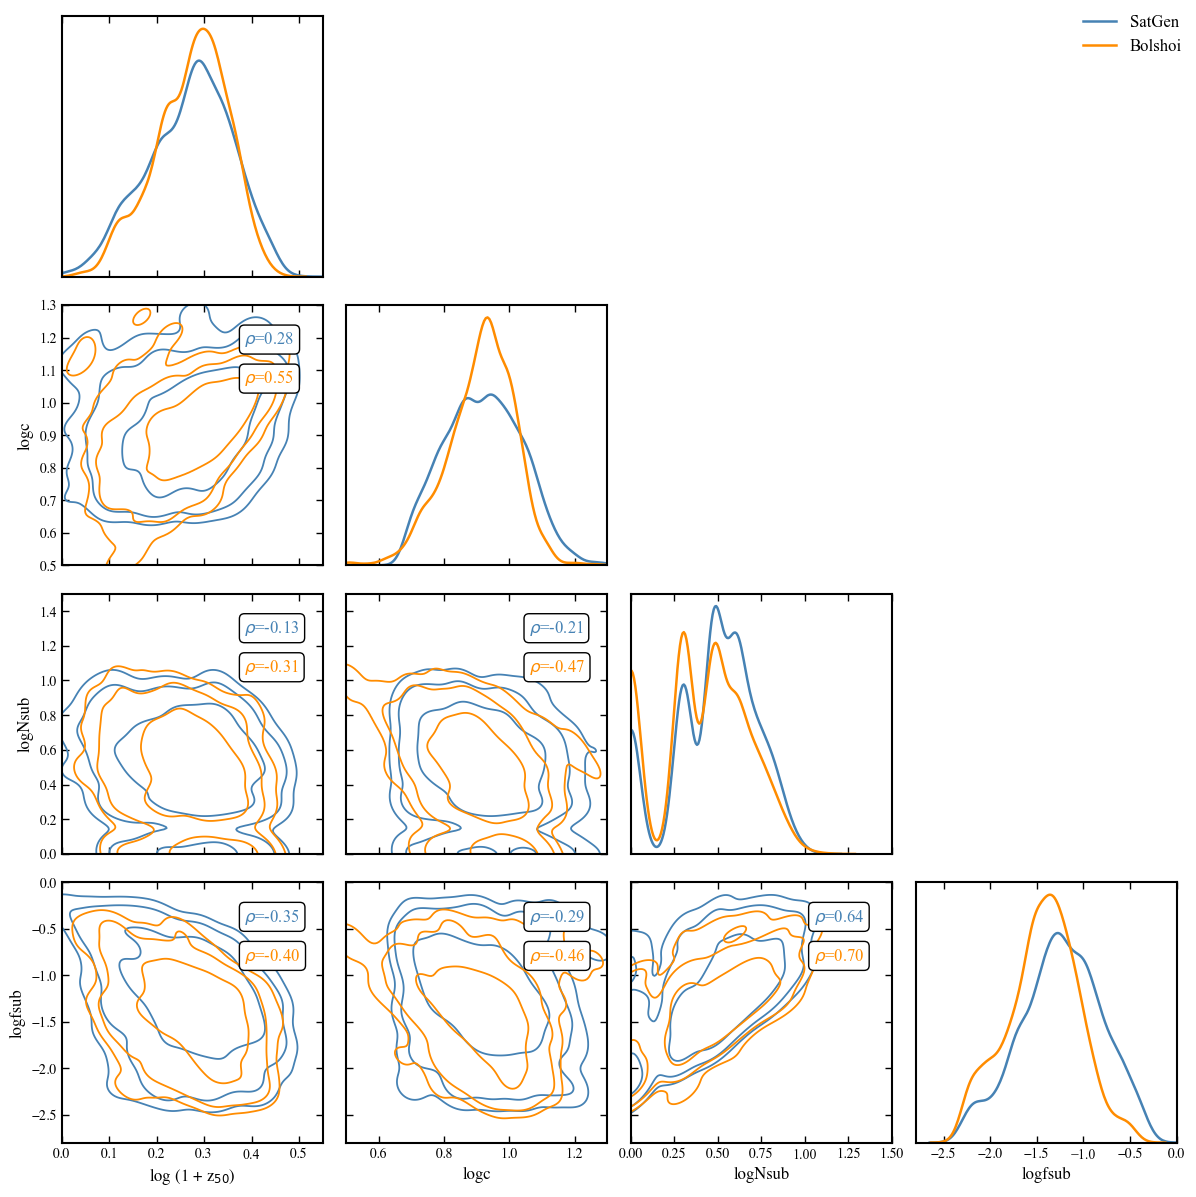

In [55]:
test = plot_corner_with_corr(matched_zhao)

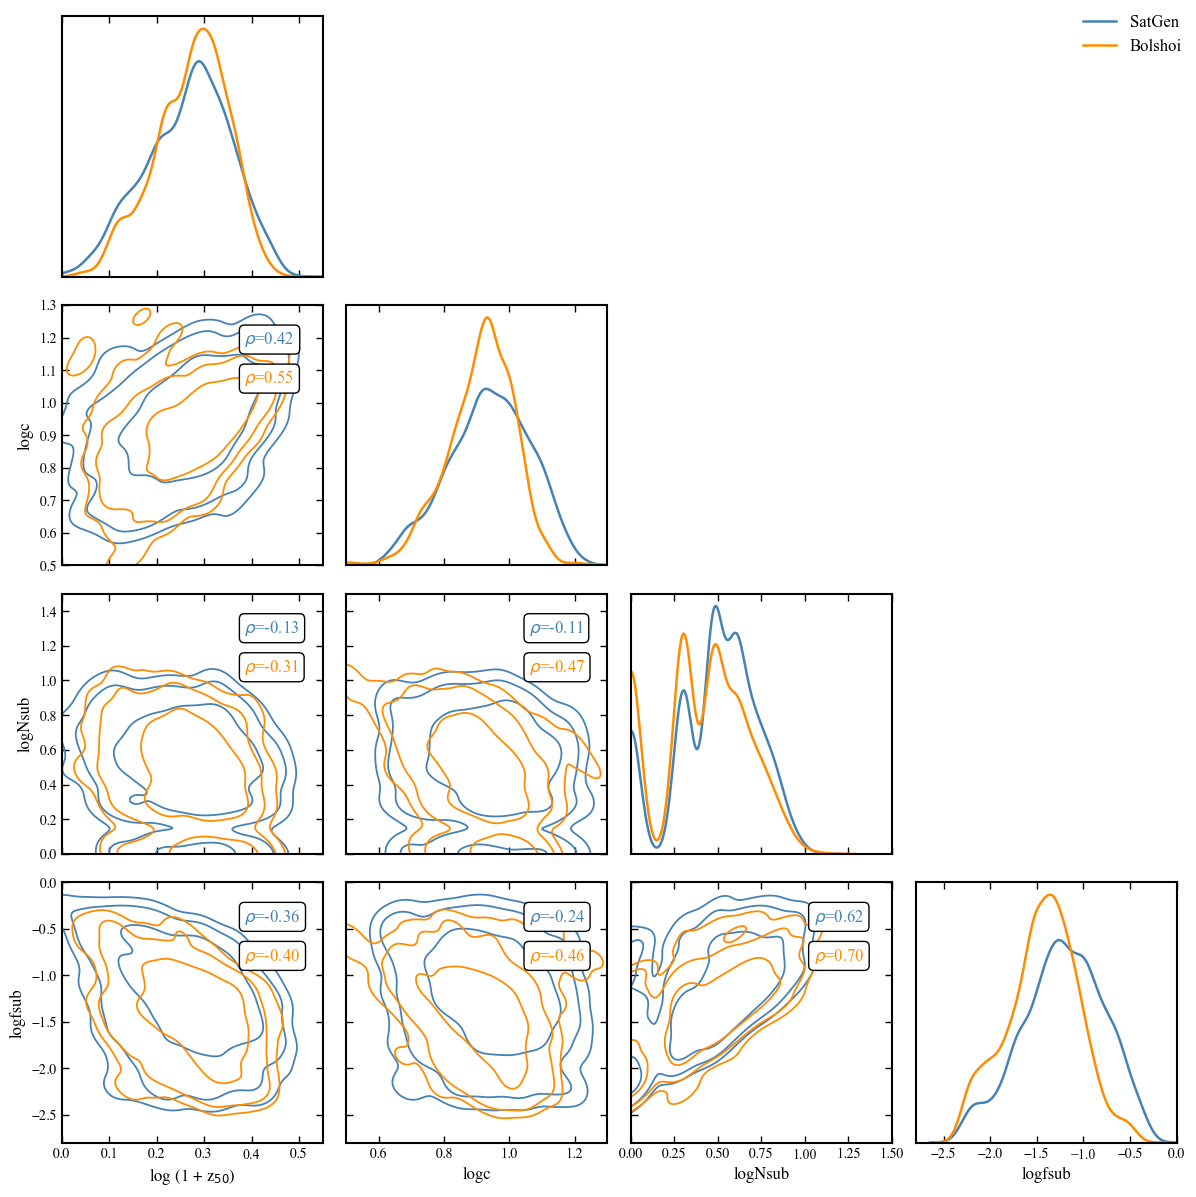

In [57]:
test = plot_corner_with_corr(matched_vanilla)

In [18]:
# this stuff is based on an older version of the way we compute fsub and Nsub 
## can still use the DF and alpha model permutations to run our new abundance code but for now lets leave it be.

# fid_tot = jsm_ancillary.load_samples("../../data/bolshoi_rep/fid.h5")
# fid_rvir = jsm_ancillary.load_samples("../../data/bolshoi_rep/fid.h5")
# fid = jsm_ancillary.load_samples("../../data/bolshoi_rep/fid.h5")

# alpha_up = jsm_ancillary.load_samples("../../data/bolshoi_rep/alpha_up.h5")
# alpha_down = jsm_ancillary.load_samples("../../data/bolshoi_rep/alpha_down.h5")
# DF_up = jsm_ancillary.load_samples("../../data/bolshoi_rep/DF_up.h5")
# DF_down = jsm_ancillary.load_samples("../../data/bolshoi_rep/DF_down.h5")

# bolshoi = pd.read_csv("../../data/summary_tabs/bolshoi_full.csv")
# bin_min = 13.1
# bin_max = 13.3
# subsample = bolshoi[(bolshoi["logMvir"] > bin_min) & (bolshoi["logMvir"] < bin_max)]
# bolshoi = subsample[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]]

In [19]:
# corner_comp = plot_corner_with_corr(
#     chains=[DF_down, fid, DF_up],
#     base_labels=["$\\beta$ = 0.075", "$\\beta$ = 0.75", "$\\beta$ = 7.5"],
#     corr_func=jsm_stats.correlation,
#     colors=["greens", "blues", "reds"],
#     paramNames=["logMvir", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"],
#     paramRanges=[[13.1, 13.3], [0.0, 0.55], [0.5, 1.3], [0.6, 2.1], [-2.8, 0]]
# )

In [20]:
# corner_comp = plot_corner_with_corr(
#     chains=[fid_tot, fid_rvir, fid],
#     base_labels=["N$_{\\rm tot}$", "N (< R$_{\\rm vir}$)",  "N (< R$_{\\rm vir}$) + AD"],
#     corr_func=jsm_stats.correlation,
#     colors=["purples", "reds", "blues"],
#     paramNames=["logMvir", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"],
#     paramRanges=[[13.1, 13.3], [0.0, 0.55], [0.5, 1.3], [0.6, 2.1], [-2.8, 0]]
# )

In [21]:
# corner_comp = plot_corner_with_corr(
#     chains=[fid, bolshoi],
#     base_labels=["SatGen", "Bolshoi"],
#     corr_func=jsm_stats.correlation,
#     colors=["blues", "oranges"],
#     paramNames=["logMvir", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"],
#     paramRanges=[[13.1, 13.3], [0.0, 0.55], [0.5, 1.3], [0.6, 2.1], [-2.8, 0]]
# )